<a href="https://colab.research.google.com/github/225K3125/computer_vision_oscar/blob/main/notebooks/UA2-T01%20-%20Ejemplos%20C%C3%B3digo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pillow scikit-image

In [ ]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
def mostrar_img(h,w,im):
  img = Image.open(im)
  # Redimensionar (width, height)
  img_resized = img.resize((h, w))
  # Mostrar
  plt.imshow(img_resized)
  plt.axis("off")
  plt.show()

In [ ]:
im = Image.open ("landscape_low.png")

[ 37113 133251 170838 147633 119184  90826  84424 135719 108963 100565
 101622 111926  85862  74437  84778  90378  81694  73963  66546  62559
  57672  56519  58709  42237  25560  17986   4562    890    424    184
     76      4      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      

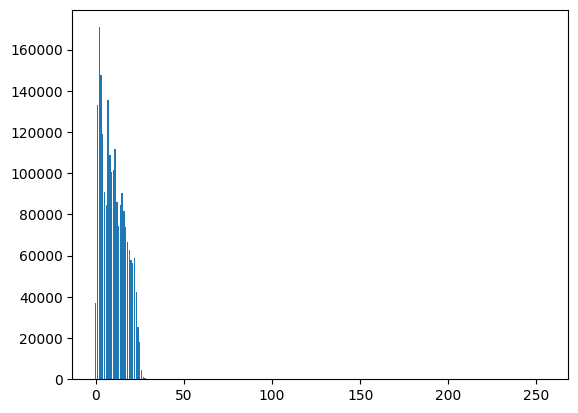

In [ ]:
I = np.asarray(im)
histogram = np.histogram(I, bins=256, range=(0, 255))
print(histogram [0])
plt.figure ()
plt.bar(range(0,256) ,histogram[0])
plt.show()

In [ ]:
im.histogram()[:10]

[37113, 133251, 170838, 147633, 119184, 90826, 84424, 135719, 108963, 100565]

In [ ]:
hist2 = [np.count_nonzero(I == i) for i in range(256)]; hist2[:10]

[37113, 133251, 170838, 147633, 119184, 90826, 84424, 135719, 108963, 100565]

In [ ]:
I2 = (I*1.25) + 32
print(I2.dtype)
I2 = np.clip(I2, 0, 255)
I2 = np.uint8(I2)
im2 = Image.fromarray(I2)
#im2

float64


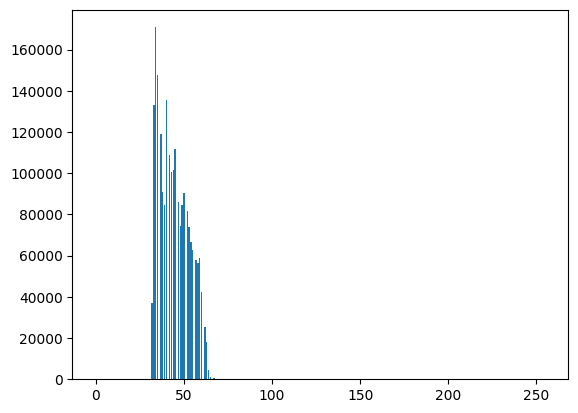

In [ ]:
histogram2 = np.histogram(I2, bins=256, range=(0, 255))

plt.figure ()
plt.bar(range(0,256) ,histogram2[0])
plt.show()

In [ ]:
from PIL import ImageEnhance

im=Image.open("landscape_low.png")
enhancer=ImageEnhance.Contrast(im)
factor = 1 #gives original image
im2 = enhancer.enhance(factor)

factor = 0
im2 = enhancer.enhance(factor)

factor = 16
im2 = enhancer.enhance(factor)

factor = 1.25
im2 = enhancer.enhance(factor)

enhancer2 = ImageEnhance.Brightness(im2)
im3 = enhancer2.enhance(10)

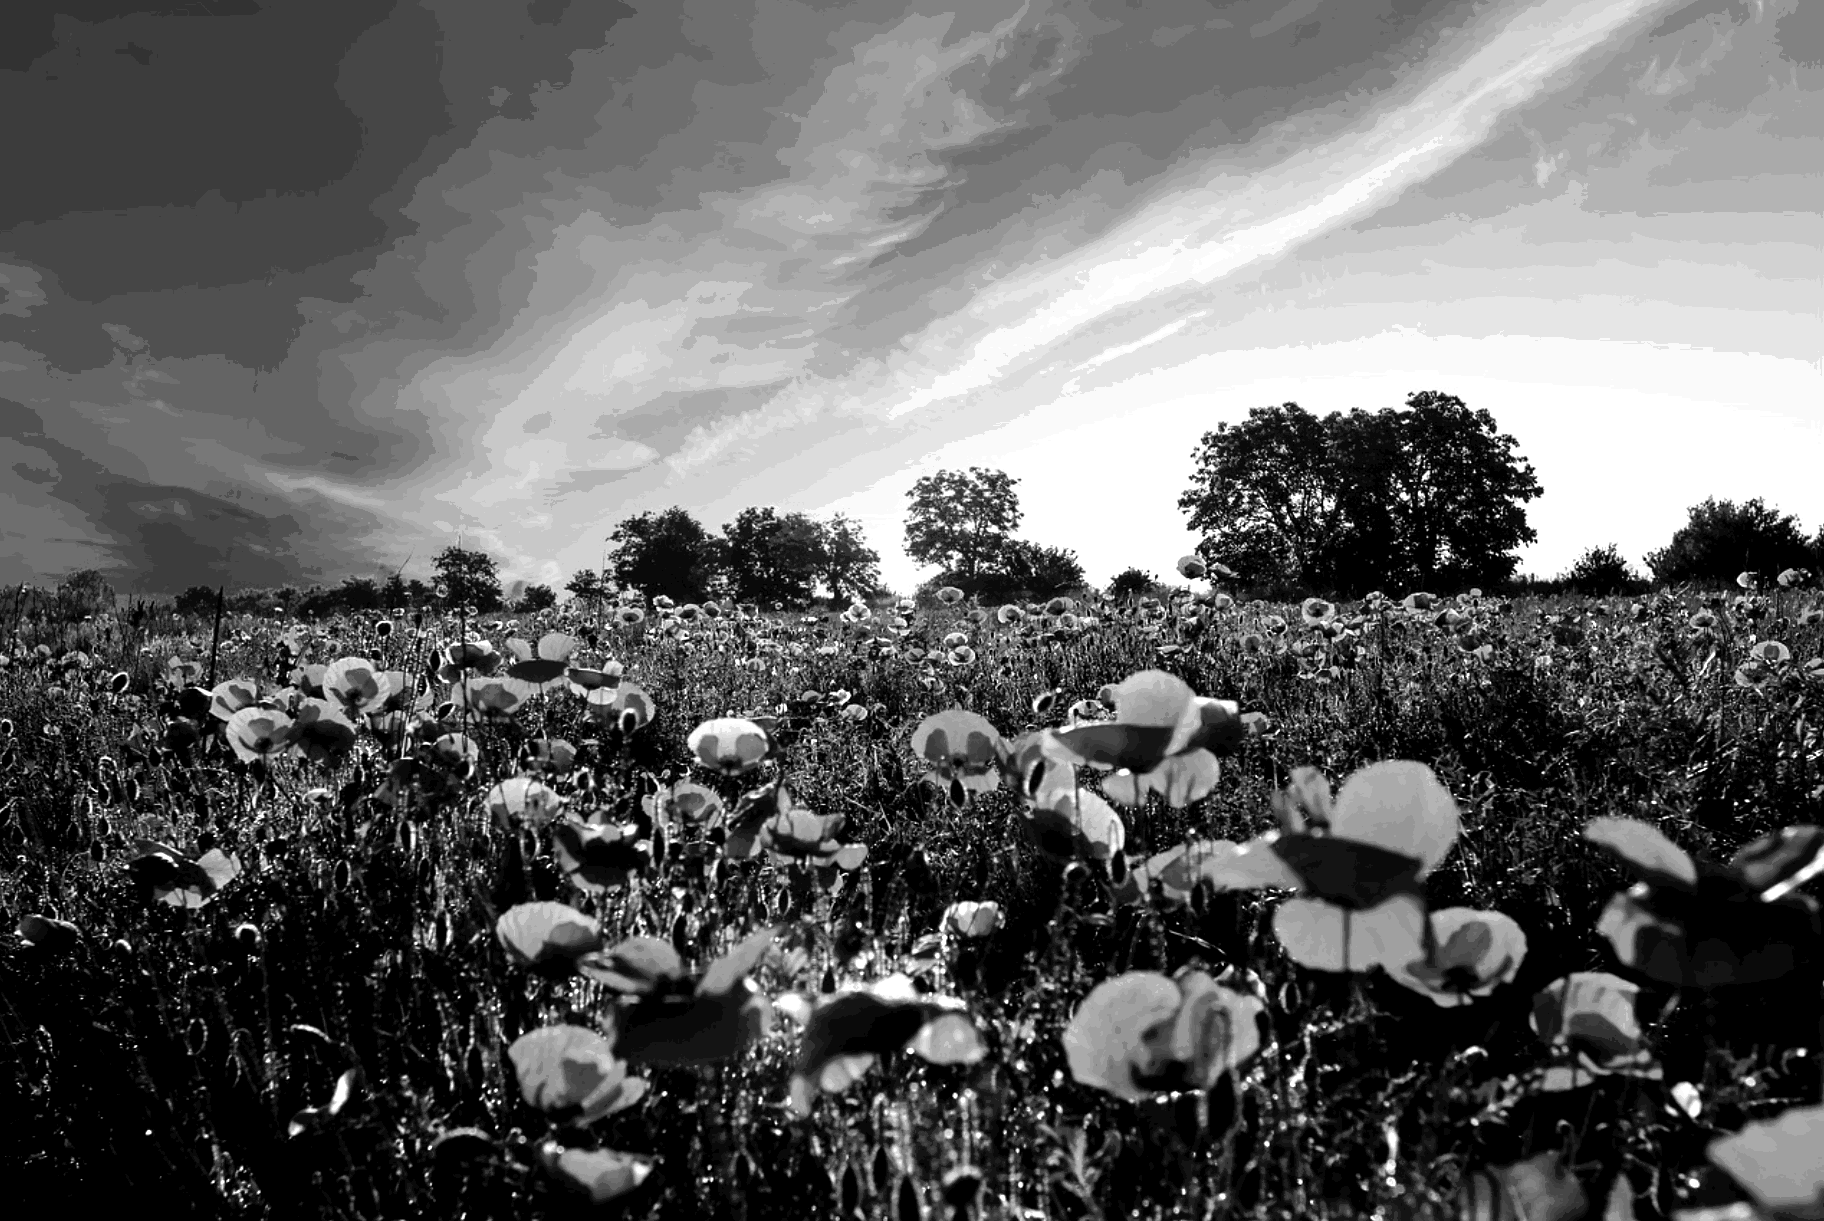

In [ ]:
im3

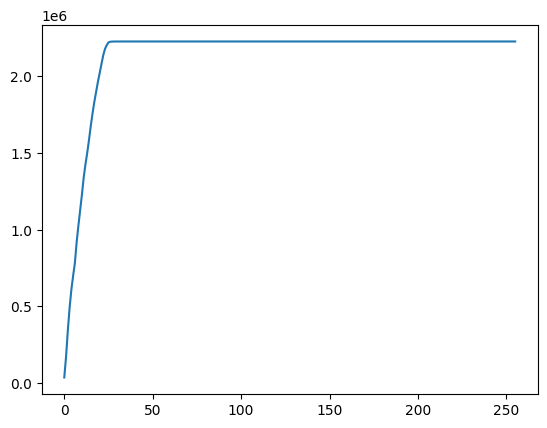

In [ ]:
## ECUALIZACIÓN 1
f = [np.count_nonzero(I <= i) for i in range(256)]
plt.figure()
plt.plot(range (0,256), f)
plt.show()

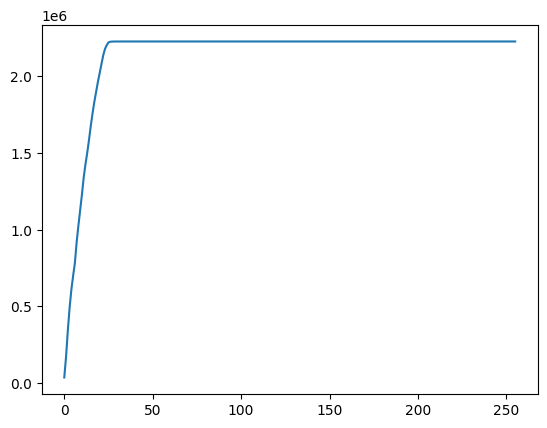

In [ ]:
## ECUALIZACIÓN 2
H = [(255.0 / I.size)*f[g] for g in range(256)]
plt.figure()
plt.plot(range (0,256), f)
plt.show()

In [ ]:
def Transform(g):
  return np.uint8(H[g])

im2 = im.point(Transform)

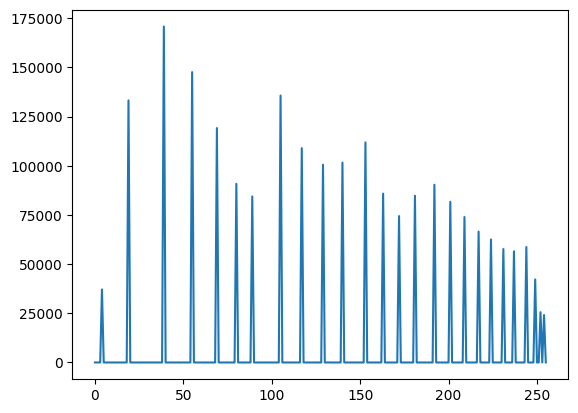

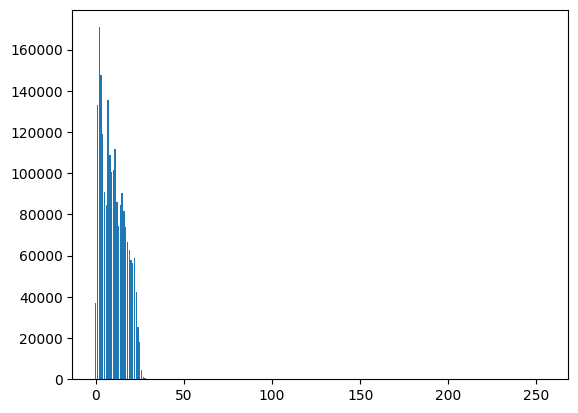

In [ ]:
## ecualizado
h = im2.histogram()
plt.figure()
plt.plot(range (0,256), h)
plt.show()

## original
plt.figure ()
plt.bar(range(0,256) ,histogram[0])
plt.show()

In [ ]:
#im2

## ECUALIZADO ADAPTATIVO

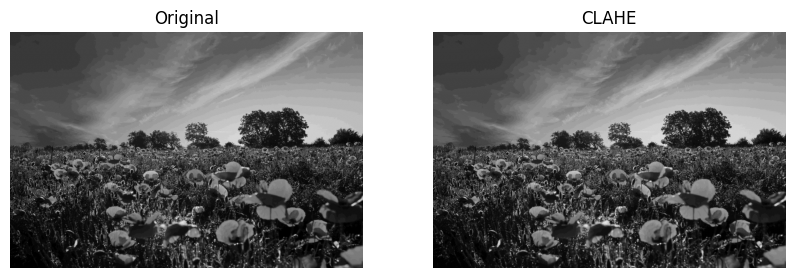

In [ ]:
import skimage.io
from skimage import exposure
from matplotlib import pyplot as plt

# Cargar imagen
im = skimage.io.imread("landscape_low.png")

# Ecualización adaptativa (CLAHE)
hi = exposure.equalize_adapthist(im)

# Mostrar
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(im, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("CLAHE")
plt.imshow(hi, cmap='gray')
plt.axis("off")

plt.show()

## Ecualización de Color

In [ ]:
from PIL import ImageCms
im = Image.open("landscape_color.png")
if im.mode != "RGB":
    im = im.convert("RGB")

srgb_profile = ImageCms.createProfile("sRGB")
lab_profile = ImageCms.createProfile("LAB")

rgb2lab_transform = ImageCms.buildTransformFromOpenProfiles(srgb_profile, lab_profile, "RGB", "LAB")
lab_im = ImageCms.applyTransform(im, rgb2lab_transform)

## Ecualizar L
lab2rgb_transform = ImageCms.buildTransformFromOpenProfiles(lab_profile,srgb_profile, "LAB", "RGB")
rgb_im = ImageCms.applyTransform(lab_im, lab2rgb_transform)

In [ ]:
rgb_im

## Con OpenCV

In [ ]:
import cv2

In [ ]:
# =========================
# 1. CARGAR IMAGEN
# =========================
img = cv2.imread("landscape_low.png")  # Cambia por tu ruta
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

(0.0, 256.0)

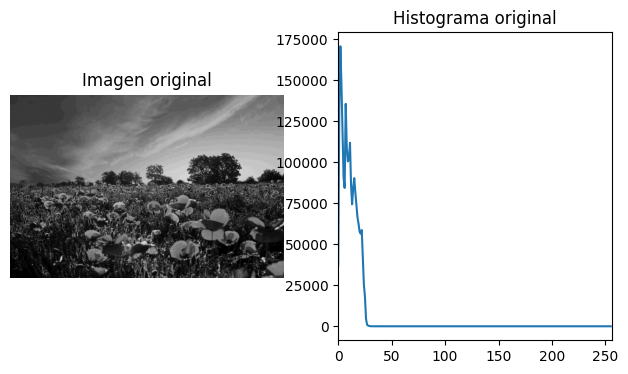

In [ ]:
# =========================
# 2. HISTOGRAMA ORIGINAL
# =========================
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Imagen original")
plt.imshow(img_gray, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Histograma original")
plt.plot(hist)
plt.xlim([0,256])

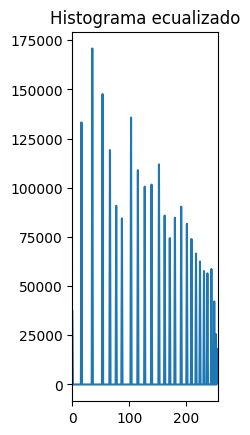

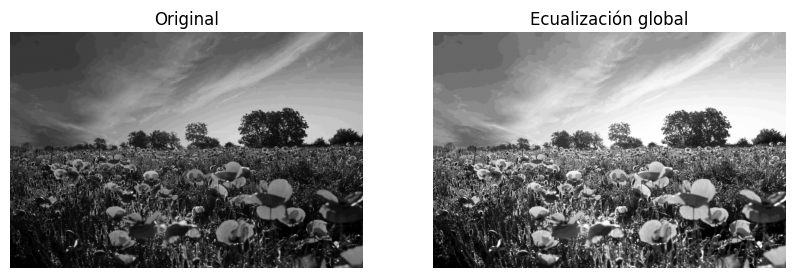

In [ ]:
# =========================
# 3. ECUALIZACIÓN GLOBAL
# =========================
img_eq = cv2.equalizeHist(img_gray)

hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0,256])

plt.subplot(1,3,3)
plt.title("Histograma ecualizado")
plt.plot(hist_eq)
plt.xlim([0,256])

plt.show()

# Mostrar comparación
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_gray, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Ecualización global")
plt.imshow(img_eq, cmap='gray')
plt.axis("off")

plt.show()

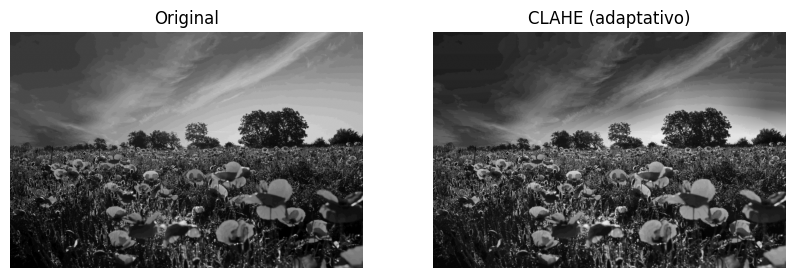

In [ ]:
# =========================
# 4. CLAHE (ECUALIZACIÓN ADAPTATIVA)
# =========================
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_gray)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_gray, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("CLAHE (adaptativo)")
plt.imshow(img_clahe, cmap='gray')
plt.axis("off")

plt.show()

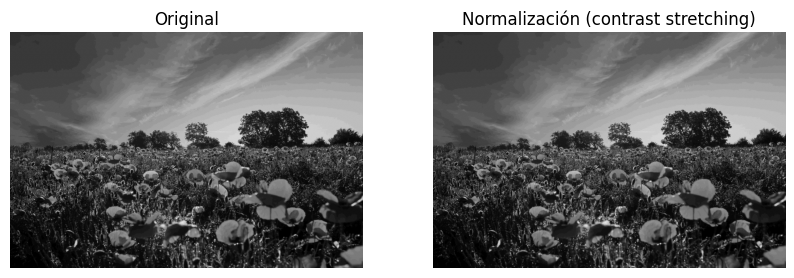

In [ ]:
# =========================
# 5. NORMALIZACIÓN (stretching)
# =========================
img_norm = cv2.normalize(img_gray, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_gray, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Normalización (contrast stretching)")
plt.imshow(img_norm, cmap='gray')
plt.axis("off")

plt.show()